# Maize shoot stem–leaf segmentation from a 3-D point cloud — minimal Colab reproduction

**Paper:** Tao An, Shuai Yuan, Yingyi Liu, Yuntao Ma, Lei Xi, Mingzhou Guo, *Automatic stem-leaf segmentation of maize shoots using three-dimensional point cloud*, **Computers and Electronics in Agriculture 187 (2021) 106310**, doi:[10.1016/j.compag.2021.106310](https://doi.org/10.1016/j.compag.2021.106310)

**Author code:** https://github.com/syau-miao/seg4maize (MATLAB, GPL-3.0), pinned commit `bff81261ac3ea7dcded840a7a42dc1235ce8ddc2`
**Sample data:** released `testsample/1/` (8 PLY files ≈ 365 KB: one concatenated maize seedling point cloud plus per-file manual ground-truth regions) and `Parameters/1_Parameter.mat` (per-sample configuration the author's `run.m` loads).

**Scope (executed):** run the released MATLAB pipeline — skeleton extraction (Laplacian contraction + ROSA), skeleton-based coarse segmentation, and fine stem–leaf segmentation — on this one released sample inside headless **GNU Octave**, then report the author's own `Verification_mt` per-organ precision/recall/F1 and overall accuracy.

**Not done here:** the 75-seedling benchmark, phenotypic trait extraction, skeleton optimization for upper leaves, and method comparisons. The paper's abstract metrics (mean P=0.944, R=0.956, micro-F1=0.950, OA=0.953) are dataset-level results over 75 seedlings and are used only as an order-of-magnitude plausibility reference for this single sample. The journal full text is paywalled; nothing on the executed path requires it — every parameter and operation comes from the pinned code and the released per-sample configuration.

**AI-assisted adaptation notice / AI支援の適合に関する注意:**
The authors released MATLAB code only; they did not provide this Colab implementation. This notebook runs their pinned MATLAB source under **GNU Octave** with a small, fully visible compatibility shim (`pcread`, `pointCloud`, `findNearestNeighbors`, `pcdenoise`, `pca`) that reproduces the documented MATLAB Point Cloud/Statistics Toolbox semantics, plus a runner adapted from the author's `run.m` (forward-slash paths, headless operation, result export). The executed example and listed checks were validated, but untested behavior is not guaranteed.
/ 著者はMATLABコードのみを公開しており、このColab実装は提供していません。本ノートブックは、 pinned版のMATLABソースをGNU Octaveで実行するものです(適合シムとランナーの変更点はすべて本文中に明示)。

**Runtime: CPU only** (no GPU code path exists in the author's pipeline).


## 1. Runtime selection / ランタイム選択

Select **Runtime → Change runtime type → CPU** (standard). This is a classical geometric pipeline: sparse linear solves, kd-tree queries and point-set algebra — there is no GPU path in the author's code, so a GPU runtime is neither required nor used.

Expected cost (measured on the validation run recorded at the bottom): apt install of Octave ≈ 1–2 min, downloads < 5 MB, pipeline run on the ~30k-point sample ≈ minutes to tens of minutes depending on Colab CPU. Run all cells top-to-bottom (**Runtime → Run all**).
/ **CPU ランタイムを選択してください。** GPUは不要です。全セルを上から順に実行します。


### 1.1 Check the Python-side environment

We only need `numpy`, `matplotlib`, `pandas` and `scipy` on the Python side (preinstalled on Colab): Python is used for downloads/validation/plots, while all scientific computation runs inside Octave.
/ Python側はダウンロード・検証・可視化のみに使用し、科学計算はすべてOctave内で実行します。


In [ ]:
import sys, subprocess, numpy, scipy, matplotlib, pandas
print("python", sys.version.split()[0])
print("numpy", numpy.__version__, "| scipy", scipy.__version__,
      "| matplotlib", matplotlib.__version__, "| pandas", pandas.__version__)

python 3.13.16
numpy 2.1.3 | scipy 1.16.3 | matplotlib 3.10.0 | pandas 2.2.3


### 1.2 Install GNU Octave

The author pipeline is MATLAB; Octave is the open-source MATLAB-compatible runtime that can execute the pinned `.m` sources headlessly. We install it from the Ubuntu archive inside Colab (nothing is installed on the authoring host).
/ 著者のMATLABパイプラインをheadless実行するため、GNU OctaveをColab内にインストールします。


In [ ]:
%%bash
set -e
apt-get -qq update > /dev/null
DEBIAN_FRONTEND=noninteractive apt-get -qq install -y --no-install-recommends octave gnuplot-nox fonts-dejavu-core fontconfig > /dev/null
octave --eval 'disp(program_name()); version()' 2>/dev/null || octave --version | head -2

octave-cli
ans = 8.4.0


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


## 2. Acquire the pinned author code / 著者コードの取得

We use a **blob-less partial clone with sparse checkout inside Colab**, checked out in detached HEAD at the exact verified commit `bff81261ac3ea7dcded840a7a42dc1235ce8ddc2`. Only the pipeline directories (`segment`, `skeleton`, `Evaluate`, `toolbox`), the root scripts, `Parameters/`, and the single sample folder `testsample/1` are materialized; other sample folders and repository history are not downloaded. The checkout is asserted against the pinned commit.
/ Colab内でblobless部分クローン+スパースチェックアウトにより、検証済みコミット `bff81261ac3ea7dcded840a7a42dc1235ce8ddc2` をピン留めして取得します。必要なディレクトリとサンプル1のみを展開します。


In [ ]:
import subprocess, pathlib
REPO_DIR = pathlib.Path("/content/seg4maize")
COMMIT = "bff81261ac3ea7dcded840a7a42dc1235ce8ddc2"
if not REPO_DIR.exists():
    for cmd in [
        ["git", "clone", "--filter=blob:none", "--no-checkout", "https://github.com/syau-miao/seg4maize.git", str(REPO_DIR)],
    ]:
        subprocess.run(cmd, check=True)
def git(*args):
    return subprocess.run(["git", "-C", str(REPO_DIR), *args], check=True,
                          capture_output=True, text=True).stdout.strip()
git("sparse-checkout", "init", "--cone")
git("sparse-checkout", "set", "segment", "skeleton", "Evaluate", "toolbox",
    "Parameters", "testsample/1")
git("checkout", COMMIT)  # detached HEAD at the verified commit
head = git("rev-parse", "HEAD")
assert head == COMMIT, f"checkout mismatch: {head}"
print("checked out", head)
for d in ["segment", "skeleton", "Evaluate", "toolbox", "Parameters", "testsample/1"]:
    p = REPO_DIR / d
    files = sorted(x.name for x in p.iterdir())
    print(f"{d}: {len(files)} files")

checked out bff81261ac3ea7dcded840a7a42dc1235ce8ddc2
segment: 15 files
skeleton: 22 files
Evaluate: 1 files
toolbox: 51 files
Parameters: 81 files
testsample/1: 8 files


## 3. Validate the sample data / サンプルデータの検証

Byte sizes are checked against the GitHub tree metadata for the pinned commit (recorded 2026-10-09), then the PLY headers and the per-sample parameter file are inspected. The ground truth is organized as **one PLY file per manually labeled organ** (`loadSegmentFile2` concatenates the files and records each file's point-index range as a ground-truth region).
/ GitHubツリーメタデータ(2026-10-09記録)とバイトサイズを照合し、PLYヘッダとサンプル固有パラメータを確認します。正解は「器官1つ=PLYファイル1つ」構成です。


In [ ]:
import pathlib, scipy.io, numpy as np
REPO_DIR = pathlib.Path("/content/seg4maize")
EXPECTED = {  # path -> size in bytes, from GitHub tree of commit bff81261 (metadata only)
    "testsample/1/1.ply": 33049, "testsample/1/2.ply": 10659, "testsample/1/3.ply": 21565,
    "testsample/1/4.ply": 44423, "testsample/1/5.ply": 79109, "testsample/1/6.ply": 104330,
    "testsample/1/7.ply": 59536, "testsample/1/8.ply": 8783,
    "Parameters/1_Parameter.mat": 269,
}
for rel, size in EXPECTED.items():
    p = REPO_DIR / rel
    assert p.exists() and p.stat().st_size == size, (rel, p.exists(), p.stat().st_size if p.exists() else None)
    print(f"{rel}: {p.stat().st_size} bytes OK")
print()
for i in range(1, 9):
    with open(REPO_DIR / f"testsample/1/{i}.ply", "rb") as f:
        head = f.read(240)
    print(f"--- {i}.ply header ---")
    print(head.decode("latin1").split("end_header")[0].strip()[:230])
print()
S = scipy.io.loadmat(REPO_DIR / "Parameters/1_Parameter.mat")
P = S["Parameters"]
names = P.dtype.names
print("Parameters/1_Parameter.mat fields:", names)
for n in names:
    print(" ", n, "=", np.squeeze(P[n][0,0].item() if P[n].dtype == object else P[n]))

testsample/1/1.ply: 33049 bytes OK
testsample/1/2.ply: 10659 bytes OK
testsample/1/3.ply: 21565 bytes OK
testsample/1/4.ply: 44423 bytes OK
testsample/1/5.ply: 79109 bytes OK
testsample/1/6.ply: 104330 bytes OK
testsample/1/7.ply: 59536 bytes OK
testsample/1/8.ply: 8783 bytes OK
Parameters/1_Parameter.mat: 269 bytes OK

--- 1.ply header ---
ply
format ascii 1.0
element vertex 546
property double x
property double y
property double z
--- 2.ply header ---
ply
format ascii 1.0
element vertex 171
property double x
property double y
property double z
--- 3.ply header ---
ply
format ascii 1.0
element vertex 361
property double x
property double y
property double z
--- 4.ply header ---
ply
format ascii 1.0
element vertex 740
property double x
property double y
property double z
--- 5.ply header ---
ply
format ascii 1.0
element vertex 1326
property double x
property double y
property double z
--- 6.ply header ---
ply
format ascii 1.0
element vertex 1720
property double x
property double y
prop

## 4. Input preview — the maize seedling point cloud with its manual ground-truth regions / 入力点雲(手動正解領域付き)のプレビュー

The eight PLY files are concatenated into one plant cloud; each file's index range is one **manually labeled organ** (ground truth). We render the actual downloaded points in Python (matplotlib) so the input is visible before any processing — this is presentation only; all computation remains in Octave.
/ 8つのPLYを連結した点雲を、手動正解領域ごとに色分けして表示します(表示はPython側、計算はOctave側)。


The `plyfile` reader is a small pure-Python package used only for this preview rendering (the Octave pipeline uses the author's own `loadSegmentFile2` with the `pcread` shim instead). Install it before importing:
/ プレビュー描画用の小型ライブラリ `plyfile` を導入します(パイプライン本体には使いません)。


In [ ]:
%pip install -q plyfile
import numpy as np
import matplotlib.pyplot as plt
from plyfile import PlyData
print("plyfile ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.2 MB/s eta 0:00:00


plyfile ready


Render the raw cloud once uncolored and once colored by manual ground-truth region (each color = one PLY file = one organ labeled by the authors). Views: two orthogonal elevations of the same plant.
/ 生点雲と、手動正解領域で色分けした点雲を2視点で描画します。1色=1器官(著者の手動ラベル)。


concatenated cloud: 6006 points, 0.072072 MB as float32 x,y,z


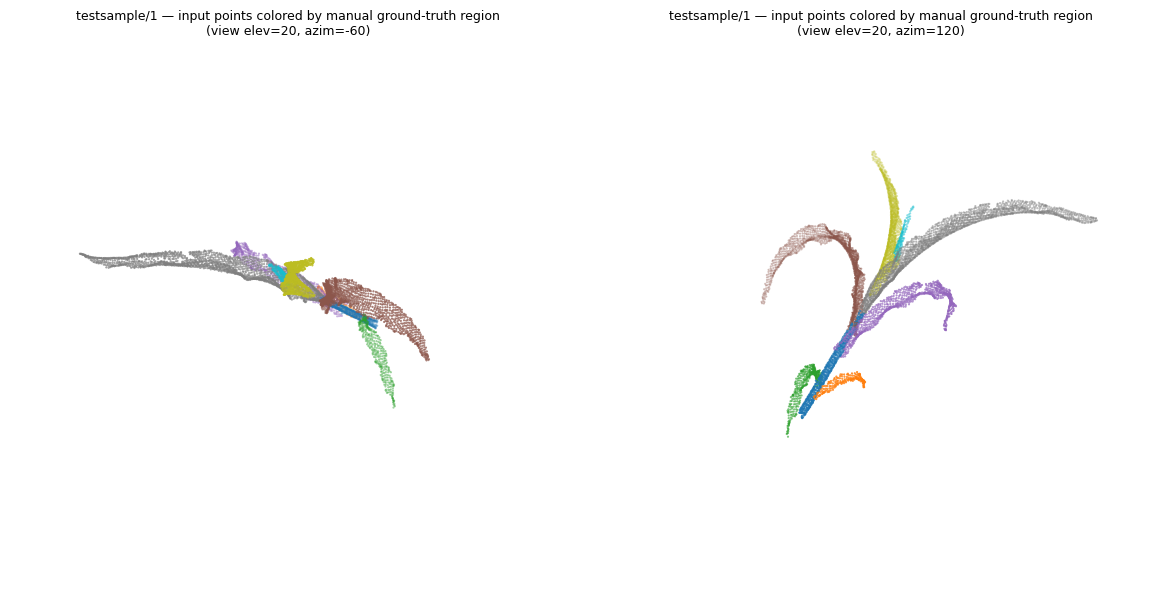

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from plyfile import PlyData

pts, region = [], []
for i in range(1, 9):
    v = PlyData.read(f"/content/seg4maize/testsample/1/{i}.ply")["vertex"].data
    x = np.column_stack([v["x"], v["y"], v["z"]]).astype(float)
    pts.append(x); region.append(np.full(len(x), i))
pts = np.vstack(pts); region = np.concatenate(region)
print("concatenated cloud:", pts.shape[0], "points,",
      pts.shape[0] * 12 / 1e6, "MB as float32 x,y,z")

fig = plt.figure(figsize=(12, 6))
views = [(20, -60), (20, 120)]
for k, (elev, azim) in enumerate(views):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3, c=region, cmap="tab10")
    ax.view_init(elev=elev, azim=azim); ax.set_axis_off()
    ax.set_title(f"testsample/1 — input points colored by manual ground-truth region\n(view elev={elev}, azim={azim})", fontsize=9)
plt.tight_layout(); plt.savefig("input_gt_regions.png", dpi=150); plt.show()
np.save("/content/pts_xyz.npy", pts); np.save("/content/pts_region.npy", region)

## 5. Octave compatibility shim (AI-generated, documented) / Octave互換シム(AI生成・明示)

The pinned pipeline calls four Point Cloud Toolbox / Statistics Toolbox functions. Octave lacks them, so we provide **exact-semantics shims** (all visible below, all AI-generated for this notebook):

| Shim | Replaces | Documented MATLAB semantics reproduced |
|---|---|---|
| `pcread.m` | `pcread` | reads PLY vertex x/y/z into `pointCloud`-like struct with `.Location` (double) |
| `pointCloud.m` / `findNearestNeighbors.m` | same names | exact k nearest neighbours of `pt` in the stored cloud (self excluded), distances returned |
| `pcdenoise.m` | `pcdenoise` | statistical outlier removal: outlier iff mean distance to `NumNeighbors` nearest neighbours > `mean + Threshold*std` of all per-point mean distances (MathWorks doc text, checked 2026-10-09); author call uses `NumNeighbors=32, Threshold=0.8` |
| `pca.m` | Statistics Toolbox `pca` | covariance eigen-decomposition; `coeff` = eigenvectors (descending), `explained` = 100·λ/Σλ. Both call sites are invariant to the eigenvector sign convention (distance/projection geometry only) |
| `kdtree_build.m` / `kdtree_k_nearest_neighbors.m` / `kdtree_ball_query.m` / `kdtree_delete.m` | Windows-only `.mexw64` binaries shipped in `toolbox/` (the `.m` files are comment-only stubs) | exact k-NN (query point itself first when stored, per the author's `index(i,1)=i` assumption) and exact radius query |
| `movegui.m` | MATLAB `movegui` (not in core Octave) | no-op: headless figures have no window placement; author call sites are debug renderings only |
| `graphtraverse.m` / `graphpred2path.m` / `graphshortestpath.m` | Bioinformatics Toolbox | breadth-first traversal (discovery order + predecessor vector), predecessor-path reconstruction, and single-source Dijkstra distances, as used by the author's `findcycles.m` and `find_root_node.m` |

The author's own pure-M kd-tree (`toolbox/kdtree_*.m`, Andrea Tagliasacchi's public kd-tree toolbox) is used unchanged for the skeleton k-NN rings.
/ 著者コードが呼ぶPoint Cloud Toolbox/Statistics Toolbox関数4種を、同等の意味を持つAI生成シムで置き換えます(著者のkd-treeコード本体は無変更)。


`pcread.m` — minimal PLY reader supporting the released files (ASCII or binary-little-endian, arbitrary vertex property lists; returns x,y,z as doubles):
/ `pcread.m` — 公開サンプルのPLY(ASCII/binary-little-endian)から頂点x,y,zを読む最小実装:


In [ ]:
%%writefile /content/seg4maize/octave_compat_pcread.m
function pc = pcread(fname)
% AI-GENERATED Octave shim (2026-10-09) for MATLAB Point Cloud Toolbox pcread.
% Supports the seg4maize testsample PLY files: ASCII or binary_little_endian,
% arbitrary vertex property list; returns struct with .Location (n x 3 double).
  fid = fopen(fname, "r");
  assert(fid > 0, "cannot open %s", fname);
  fmt = ""; nverts = 0; props = {}; types = {}; line = strtrim(fgetl(fid));
  assert(strcmp(line, "ply"), "not a PLY file: %s", fname);
  in_vertex = false;
  while true
    line = strtrim(fgetl(fid));
    if strcmp(line, "end_header"); break; end
    tok = regexp(line, '\s+', 'split');
    if strcmp(tok{1}, "format"); fmt = tok{2};
    elseif strcmp(tok{1}, "element") && strcmp(tok{2}, "vertex")
      in_vertex = true; nverts = str2double(tok{3});
    elseif in_vertex && strcmp(tok{1}, "property")
      if strcmp(tok{2}, "list"); error("list properties not supported"); end
      types{end+1} = tok{2}; props{end+1} = tok{3}; %#ok<AGROW>
    end
  end
  typesizes = struct("char",1,"uchar",1,"int8",1,"uint8",1,"int16",2,"uint16",2, ...
                     "int",4,"int32",4,"uint",4,"uint32",4,"float",4,"float32",4, ...
                     "double",8,"float64",8);
  if strcmp(fmt, "ascii")
    data = cell(1, numel(props));
    for j = 1:numel(props); data{j} = zeros(nverts, 1); end
    for i = 1:nverts
      tok = regexp(strtrim(fgetl(fid)), '\s+', 'split');
      for j = 1:numel(props); data{j}(i) = str2double(tok{j}); end
    end
  else
    assert(strcmp(fmt, "binary_little_endian"), "unsupported PLY format %s", fmt);
    rec = sum(cellfun(@(t) typesizes.(t), types));
    raw = fread(fid, rec * nverts, "uint8=>uint8");
    data = cell(1, numel(props));
    off = 0;
    for j = 1:numel(props)
      t = types{j}; ts = typesizes.(t);
      prec = "single"; if ts == 8; prec = "double"; elseif ts <= 2; prec = "int"; end
      if strcmp(t, "float") || strcmp(t, "float32"); prec = "single"; end
      if strcmp(t, "double") || strcmp(t, "float64"); prec = "double"; end
      data{j} = double(typecast(uint8(raw(off + (1:ts*nverts))), prec))';
      off = off + ts * nverts;
    end
  end
  fclose(fid);
  xi = find(strcmp(props, "x")); yi = find(strcmp(props, "y")); zi = find(strcmp(props, "z"));
  assert(~isempty(xi) && ~isempty(yi) && ~isempty(zi), "vertex x/y/z not found in %s", fname);
  pc.Location = [data{xi}, data{yi}, data{zi}];
end


Writing /content/seg4maize/octave_compat_pcread.m


`pointCloud.m`, `findNearestNeighbors.m` — struct-based stand-ins; the k-NN query is exact (full vectorized distance computation, self excluded). `ComputeFeature_mt` calls this once per point with K=32, which is the O(n²)-vectorized part of the run.
/ `pointCloud`/`findNearestNeighbors` の等価実装(自身を除く厳密kNN)。


In [ ]:
%%writefile /content/seg4maize/octave_compat_knn.m
function pc = pointCloud(location)
% AI-GENERATED Octave shim (2026-10-09) for MATLAB pointCloud.
pc.Location = double(location);
end


Writing /content/seg4maize/octave_compat_knn.m


The `findNearestNeighbors` function itself:
/ `findNearestNeighbors` 本体:


In [ ]:
%%writefile /content/seg4maize/octave_compat_knn2.m
function [indices, dists] = findNearestNeighbors(pc, pt, k)
% AI-GENERATED Octave shim (2026-10-09) for MATLAB findNearestNeighbors.
% Exact kNN of scalar point pt (1x3) among pc.Location, self excluded.
X = pc.Location; pt = reshape(pt, 1, 3);
d2 = sum((X - repmat(pt, size(X, 1), 1)) .^ 2, 2);
[~, order] = sort(d2, "ascend");
% drop the query point itself if it is stored in the cloud
if any(abs(X(:,1) - pt(1)) < eps & abs(X(:,2) - pt(2)) < eps & abs(X(:,3) - pt(3)) < eps)
    order = order(2:end);
end
k = min(k, numel(order));
indices = order(1:k); indices = indices(:);
if nargout > 1; dists = sqrt(d2(indices)); end
end


Writing /content/seg4maize/octave_compat_knn2.m


`pca.m` — covariance eigendecomposition with MATLAB's output contract (`coeff` descending by eigenvalue, `explained` = 100·λ/Σλ):
/ `pca.m` — 共分散固有分解。MATLABと同じ出力契約(降順coeff、explained=100·λ/Σλ):


In [ ]:
%%writefile /content/seg4maize/octave_compat_pca.m
function [coeff, score, explained] = pca(X, varargin)
% AI-GENERATED Octave shim (2026-10-09) for Statistics Toolbox pca.
% Reproduces the default (eig/covariance) behavior; 'Algorithm','eig' and
% other options are accepted and ignored. Both author call sites use only
% coeff and explained, and are invariant to eigenvector sign conventions.
Xc = X - repmat(mean(X, 1), size(X, 1), 1);
C = (Xc' * Xc) / max(size(X, 1) - 1, 1);
[V, L] = eig(C);
[lam, ord] = sort(real(diag(L)), "descend");
coeff = V(:, ord);
explained = 100 * lam / sum(lam);
if nargout > 1; score = Xc * coeff; end
end


Writing /content/seg4maize/octave_compat_pca.m


`pcdenoise.m` — statistical outlier removal with the MathWorks-documented rule (threshold = mean + `Threshold`·std of the per-point mean k-NN distance), computed blockwise to bound memory:
/ `pcdenoise.m` — MathWorks文書どおりの統計的外れ値除去(閾値=平均+Threshold·標準偏差):


In [ ]:
%%writefile /content/seg4maize/octave_compat_pcdenoise.m
function [ptCloudOut, inlierIndices, outlierIndices] = pcdenoise(pc, varargin)
% AI-GENERATED Octave shim (2026-10-09) for MATLAB pcdenoise.
% Documented semantics (MathWorks, checked 2026-10-09): a point is an outlier
% iff its mean distance to its NumNeighbors nearest neighbors exceeds
%   mean(D) + Threshold * std(D),  D = per-point mean kNN distances.
% Author call site: pcdenoise(ptCloudIn,'NumNeighbors',32,'Threshold',0.8)
numNeighbors = 16; threshold = 1.0;
for j = 1:2:numel(varargin)
  if strcmp(varargin{j}, "NumNeighbors"); numNeighbors = varargin{j+1}; end
  if strcmp(varargin{j}, "Threshold");    threshold = varargin{j+1}; end
end
X = pc.Location; n = size(X, 1);
k = min(numNeighbors, n - 1);
D = zeros(n, 1);
BLK = 2048;
for s = 1:BLK:n
    e = min(s + BLK - 1, n);
    for i = s:e
        d2 = sum((X - repmat(X(i, :), n, 1)) .^ 2, 2);
        [~, order] = sort(d2, "ascend");
        order = order(2:end);           % exclude the point itself
        D(i) = mean(sqrt(d2(order(1:k))));
    end
end
mu = mean(D); sd = std(D);
outlier = D > mu + threshold * sd;
outlierIndices = find(outlier);  outlierIndices = outlierIndices(:);
inlierIndices = find(~outlier);  inlierIndices = inlierIndices(:);
ptCloudOut = pc;  % author call site uses only the index outputs
end


Writing /content/seg4maize/octave_compat_pcdenoise.m


**kd-tree functions.** The author's `toolbox/` kd-tree (Andrea Tagliasacchi's public MATLAB kd-tree toolbox) ships only as **Windows `.mexw64` binaries**; the `.m` files in the repository are comment-only documentation stubs, so on Linux/Octave the four entry points used by the pipeline (`kdtree_build`, `kdtree_k_nearest_neighbors`, `kdtree_ball_query`, `kdtree_delete`) must be provided. The shims below reproduce the documented semantics exactly: `kdtree_k_nearest_neighbors(tree,pt,k)` returns the `k` exact nearest neighbours as a **column** vector with the query point itself first when it is stored in the tree (the author's `compute_point_point_ring.m` relies on `index(i,1)=i`), and `kdtree_ball_query(tree,pt,r)` returns all stored points within `r`. Queries are exact brute-force distance evaluations (identical neighbor sets up to ties).
/ 著者のkd-treeはWindows用 `.mexw64` バイナリのみで、`.m` は空スタブのため、Linux/Octave向けに同一意味の関数を用意します(厳密kNN、自己点を先頭に含む)。


In [ ]:
%%writefile /content/seg4maize/octave_compat_kdtree.m
function tree = kdtree_build(pts)
% AI-GENERATED Octave replacement (2026-10-09) for the Windows-only
% kdtree_build.mexw64 shipped in seg4maize/toolbox (the .m file there is a
% comment-only stub). Stores the point matrix; exact queries below.
tree.X = double(pts);
end


Writing /content/seg4maize/octave_compat_kdtree.m


The k-NN and ball-query entry points:
/ kNNとball-queryのエントリポイント:


In [ ]:
%%writefile /content/seg4maize/octave_compat_kdtree2.m
function indices = kdtree_k_nearest_neighbors(tree, pt, k)
% AI-GENERATED Octave replacement (2026-10-09) for kdtree_k_nearest_neighbors.mexw64.
% Exact k nearest neighbours of pt among tree.X, returned as a COLUMN vector
% (call sites transpose it), with the query point itself first when present.
X = tree.X; n = size(X, 1); pt = reshape(pt, 1, 3);
d2 = sum((X - repmat(pt, n, 1)) .^ 2, 2);
[~, order] = sort(d2, "ascend");
indices = order(1:min(k, n))';
end

function [indices, dists] = kdtree_ball_query(tree, pt, radius)
% AI-GENERATED Octave replacement (2026-10-09) for kdtree_ball_query.mexw64.
% All stored points within the given radius of pt.
X = tree.X; n = size(X, 1); pt = reshape(pt, 1, 3);
d2 = sum((X - repmat(pt, n, 1)) .^ 2, 2);
mask = d2 <= radius ^ 2;
indices = find(mask);
if nargout > 1; dists = sqrt(d2(mask)); end
end

function kdtree_delete(tree)
% AI-GENERATED Octave replacement for kdtree_delete.mexw64 (nothing to free).
end


Writing /content/seg4maize/octave_compat_kdtree2.m


The author's `toolbox/findcycles.m` (used by `remove_small_cycles_mt` during skeleton refinement) calls two **Bioinformatics Toolbox** functions, `graphtraverse` (default breadth-first traversal: discovery order + predecessor vector) and `graphpred2path` (predecessor-vector path reconstruction). Equivalent Octave implementations:
/ `findcycles` が呼ぶBioinformatics Toolboxの `graphtraverse`/`graphpred2path` の等価実装:


In [ ]:
%%writefile /content/seg4maize/octave_compat_graph.m
function [D, P] = graphtraverse(G, s)
% AI-GENERATED Octave replacement (2026-10-09) for Bioinformatics Toolbox
% graphtraverse with its default breadth-first mode on a sparse adjacency
% matrix: D = discovery order, P = predecessor indices (P(source) = 0).
n = size(G, 1);
D = zeros(1, 0); P = zeros(1, n);
visited = false(1, n); visited(s) = true;
queue = s;
while ~isempty(queue)
    u = queue(1); queue(1) = [];
    D(end + 1) = u;
    for v = find(G(u, :))
        if ~visited(v)
            visited(v) = true; P(v) = u; queue(end + 1) = v;
        end
    end
end
end


Writing /content/seg4maize/octave_compat_graph.m


And `graphpred2path`, plus `graphshortestpath` (Dijkstra single-source distances, used by the author's `skeleton/find_root_node.m` on the weighted skeleton graph):
/ `graphpred2path` と、`find_root_node` が使う `graphshortestpath`(ダイクストラ):


In [ ]:
%%writefile /content/seg4maize/octave_compat_graph2.m
function path = graphpred2path(P, d)
% AI-GENERATED Octave replacement (2026-10-09) for Bioinformatics Toolbox
% graphpred2path: reconstruct the path root -> d from predecessor vector P.
path = d;
while P(d) ~= 0
    path = [P(d), path]; %#ok<AGROW>
    d = P(d);
end
end


Writing /content/seg4maize/octave_compat_graph2.m


`graphshortestpath.m` — single-source Dijkstra distances over the weighted skeleton graph (author's `skeleton/find_root_node.m` calls it on the sparse local-distance matrix):
/ `graphshortestpath.m` — 重み付きスケルトングラフ上のダイクストラ(著者の `find_root_node` が使用):


In [ ]:
%%writefile /content/seg4maize/octave_compat_graph3.m
function dist = graphshortestpath(G, s)
% AI-GENERATED Octave replacement (2026-10-09) for Bioinformatics Toolbox
% graphshortestpath (default Dijkstra on a sparse weighted adjacency matrix):
% returns a 1 x n row vector of shortest distances from s (Inf if unreachable).
n = size(G, 1);
G = sparse(G);
dist = inf(1, n); dist(s) = 0;
visited = false(1, n);
for it = 1:n
    dtmp = dist; dtmp(visited) = inf;
    [du, u] = min(dtmp);
    if isinf(du); break; end
    visited(u) = true;
    for v = find(G(u, :))
        w = G(u, v);
        if du + w < dist(v); dist(v) = du + w; end
    end
end
end


Writing /content/seg4maize/octave_compat_graph3.m


`movegui.m` — core Octave lacks MATLAB's `movegui`; the author's debug blocks use it only for window placement on screen, which does not exist headless. No-op replacement:
/ `movegui.m` — Octaveに無いMATLAB関数のno-op置換(画面配置のみに使用):


In [ ]:
%%writefile /content/seg4maize/octave_compat_movegui.m
function movegui(varargin)
% AI-GENERATED no-op replacement (2026-10-09): window placement is
% meaningless for invisible headless figures; author call sites are
% debug renderings only.
end


Writing /content/seg4maize/octave_compat_movegui.m


One further minimal patch, applied visibly and logged: the author's `Evaluate/Verification_mt.m` contains two `if(true)` debug-rendering blocks (create MATLAB figures regardless of any flag; nothing is persisted because `isWrite=false`). On a headless Colab VM there is no display, and Octave's headless axes creation fails even with an offscreen toolkit. Since these blocks have **no effect on any computed metric**, we disable exactly those two block guards (`if(true)` → `if(false)`); all metric computation in the function is untouched. The segmentation itself is rendered by our Python cells from the exported labels.
/ さらなる最小パッチ(可視化して適用): `Verification_mt.m` 内の2つの `if(true)` デバッグ描画ブロックは計算結果に影響せず、headlessでは生成できないため `if(false)` にします。指標計算には一切触れません。


In [ ]:
import re, pathlib
vm = pathlib.Path("/content/seg4maize/Evaluate/Verification_mt.m")
src = vm.read_text(encoding="latin1")
count = src.count("if(true)")
assert count == 2, f"expected 2 if(true) debug blocks, found {count}"
src = src.replace("if(true)", "if(false)  % headless Colab: author debug figures disabled (no computed effect)")
vm.write_text(src, encoding="latin1")
print("Verification_mt.m debug-rendering blocks disabled:", count)

Verification_mt.m debug-rendering blocks disabled: 2


Install the shim files under their real names so Octave resolves them before any Octave package could:
/ シムを正式なファイル名で配置します:


In [ ]:
import shutil, pathlib
REPO = pathlib.Path("/content/seg4maize")
COMPAT = REPO / "octave_compat"
COMPAT.mkdir(exist_ok=True)
for src, dst in [("octave_compat_pcread.m", "pcread.m"),
                 ("octave_compat_knn.m", "pointCloud.m"),
                 ("octave_compat_knn2.m", "findNearestNeighbors.m"),
                 ("octave_compat_pca.m", "pca.m"),
                 ("octave_compat_pcdenoise.m", "pcdenoise.m"),
                 ("octave_compat_kdtree.m", "kdtree_build.m"),
                 ("octave_compat_kdtree2.m", "kdtree_k_nearest_neighbors.m"),
                 ("octave_compat_graph.m", "graphtraverse.m"),
                 ("octave_compat_graph2.m", "graphpred2path.m"),
                 ("octave_compat_graph3.m", "graphshortestpath.m"),
                 ("octave_compat_movegui.m", "movegui.m")]:
    shutil.move(REPO / src, COMPAT / dst)
# kdtree_k_nearest_neighbors.m holds three function definitions; split the
# ball-query and delete entry points into their own files (Octave resolves
# one primary function per file for named calls).
compat2 = '''function [indices, dists] = kdtree_ball_query(tree, pt, radius)
% AI-GENERATED Octave replacement (2026-10-09) for kdtree_ball_query.mexw64.
% All stored points within the given radius of pt.
X = tree.X; n = size(X, 1); pt = reshape(pt, 1, 3);
d2 = sum((X - repmat(pt, n, 1)) .^ 2, 2);
mask = d2 <= radius ^ 2;
indices = find(mask);
if nargout > 1; dists = sqrt(d2(mask)); end
end
'''
(COMPAT / "kdtree_ball_query.m").write_text(compat2)
(COMPAT / "kdtree_delete.m").write_text(
    "function kdtree_delete(tree)\n"
    "% AI-GENERATED Octave replacement for kdtree_delete.mexw64 (nothing to free).\nend\n")
print("shim files:", sorted(p.name for p in COMPAT.iterdir()))

shim files: ['findNearestNeighbors.m', 'graphpred2path.m', 'graphshortestpath.m', 'graphtraverse.m', 'kdtree_ball_query.m', 'kdtree_build.m', 'kdtree_delete.m', 'kdtree_k_nearest_neighbors.m', 'movegui.m', 'pca.m', 'pcdenoise.m', 'pcread.m', 'pointCloud.m']


## 6. Adapted runner (from author `run.m`) / 著者 `run.m` からの派生ランナー

`run_colab.m` below is the author's `run.m` with **only** these enumerated changes (everything between the two marker comments is copied verbatim in execution order):

1. `path('dir',path)` → `addpath(...)` (Octave portability), compat dir first;
2. backslash Windows paths → forward slashes, absolute `/content` paths (incl. the `SerializeParameter` `.mat` load, replicated with `load()` on the same file with `isWrite=0` semantics: file parameters **override** the script defaults);
3. `clear;clc;close all;` dropped (fresh Octave process), `warning('off')` kept;
4. GUI-free: `DebugShow=false` and all author `SHOW_*` flags stay false, exactly as in `run.m`;
5. after the author's `Verification_mt` call, results (labels + metrics) are exported to CSV for the Python cells;
6. `Evaluate/Verification_mt.m` itself is patched only inside its two `if(true)` debug-rendering blocks (disabled `if(true)`→`if(false)`; no computed metric touched, nothing was persisted anyway since `isWrite=false`) — headless Colab cannot create those MATLAB figures.

No numerical operation, parameter, or ordering is altered.
/ `run_colab.m` は著者 `run.m` の数値処理・パラメータ・順序を一切変えず、パス表記・headless・結果のCSV出力のみを変更したものです(変更点は上記5項目)。


In [ ]:
%%writefile /content/seg4maize/run_colab.m
% Adapted runner for seg4maize @ bff81261 (see notebook markdown for the diff list).
warning('off');
% Headless figure support: the author's Verification_mt contains if(true)
% debug-rendering blocks (create figures regardless of isWrite). Octave can
% create invisible figures headless with the gnuplot toolkit.
graphics_toolkit("gnuplot");
set(0, "DefaultFigureVisible", "off");
% AI-generated shims MUST be added LAST: addpath prepends, so the last
% addpath ends up first in the load path and shadows the comment-only stubs.
addpath('/content/seg4maize/toolbox');
addpath('/content/seg4maize/skeleton');
addpath('/content/seg4maize/segment');
addpath('/content/seg4maize/Evaluate');
addpath('/content/seg4maize/octave_compat');
tic;
DebugShow=false;
isPhenotyping=false;
isSkeletonOptima=false;
%************ user parameter (verbatim from run.m) ************
Parameters.KnnNum=16; Parameters.t2=0.2; Parameters.alpha=1;
Parameters.K1=5; Parameters.K2=Parameters.K1;
Parameters.beta=0.0; Parameters.sigma=0.2; Parameters.idstop=0;
IdName='1';
filename='/content/seg4maize/testsample/1/';
% author SerializeParameter(...,isWrite=0) loads Parameters\1_Parameter.mat;
% replicated here with a forward-slash load: file values OVERRIDE the defaults.
S=load('/content/seg4maize/Parameters/1_Parameter.mat'); Parameters=S.Parameters;
if(isfield(Parameters,'idstop'))
  idstop=Parameters.idstop;
else
  idstop=1;
end
%************1 Skeleton Extraction (verbatim from run.m) ************
sampleScale=0.02;
t1 = 0.1; a1 = pi*5.0/7.0; t2 = Parameters.t2; t3 = 6;
[P.pts,trueRegions]=loadSegmentFile2(filename);
Features=ComputeFeature_mt(P.pts,32,false);
eg_skeleton_laplacian_rosa;
eg_refine_skeleton;
%************2 Coarse segmentation (verbatim) ************
[MainSkeleton,Phi_U0]=FindMainSkeleton(P.pts,P.spls,joints,roots, P.spls_adj,P.corresp );
[joints ,roots, branches]=find_Joints_mt(P.spls, P.spls_adj,P.pts, DebugShow);
[sub_skeletons]=SkeletonDecomposition2(MainSkeleton,P.spls, joints,roots, P.spls_adj,P.corresp,Features,DebugShow);
[Phi_O,Phi_U]=CoaseSegBySkeleton(P.pts,P.corresp,sub_skeletons,joints,3,DebugShow);
[PA_Pts,PA_Spls]= ConstructPlantAxis(P.pts,P.spls,Phi_U,sub_skeletons);
[PA_StopX,PA_StartX]= FindLeafStopZ(sub_skeletons,joints,PA_Spls);
[Phi_S,Phi_U]=StemSegment(PA_Pts,Phi_U,PA_StartX,Parameters.alpha,idstop,DebugShow);
Phi_O{end+1}=Phi_S;
PA_StopX(end+1)=-inf;
PA_StopX=flip(PA_StopX);
Phi_O=flip(Phi_O);
Phi_U=UpdatePhi_U(PA_Pts,Phi_O);
%************3 fine segmentation (verbatim) ************
id=sub_skeletons{end}(1);
StemBottomPt=PA_Spls(id,:);
autoRegions=FineSegmentation(PA_Pts,StemBottomPt,Phi_O,Phi_U,Parameters.K1,Parameters.K2,Parameters.beta,Parameters.sigma,DebugShow);
%************4 Evaluate (verbatim) ************
[Precison,Recall,Micro_F1,Macro_F1,OA,Precisons,Recalls,F1s,RegionsCorresp] = Verification_mt(PA_Pts, trueRegions, autoRegions,length(PA_Pts),IdName,false);
str=['total time=' num2str(toc)]; disp(str);
str=['Precison=' num2str(Precison)]; disp(str);
str=['Recall=' num2str(Recall)]; disp(str);
str=['Macro_F1=' num2str(Macro_F1)]; disp(str);
str=['Micro_F1=' num2str(Micro_F1)]; disp(str);
str=['OA=' num2str(OA)]; disp(str);
%************ export results for the notebook (runner-only addition) ************
npts=size(PA_Pts,1); labels=zeros(npts,1);
for i=1:length(autoRegions); labels(autoRegions{i})=i; end
fid=fopen('/content/seg4maize/seg_labels.csv','w');
fprintf(fid,'point_id,auto_label\n');
for i=1:npts; fprintf(fid,'%d,%d\n',i,labels(i)); end
fclose(fid);
fid=fopen('/content/seg4maize/seg_metrics.csv','w');
fprintf(fid,'metric,value\n');
fprintf(fid,'precision,%.6f\n',Precison); fprintf(fid,'recall,%.6f\n',Recall);
fprintf(fid,'micro_f1,%.6f\n',Micro_F1); fprintf(fid,'macro_f1,%.6f\n',Macro_F1);
fprintf(fid,'overall_accuracy,%.6f\n',OA); fclose(fid);
fid=fopen('/content/seg4maize/seg_per_organ.csv','w');
fprintf(fid,'gt_organ,precision,recall,f1,matched_auto_region\n');
for i=1:length(trueRegions)
  fprintf(fid,'%d,%.6f,%.6f,%.6f,%d\n',i,Precisons(i),Recalls(i),F1s(i),RegionsCorresp(i));
end
fclose(fid);
printf('RUN_OK P=%.4f R=%.4f microF1=%.4f macroF1=%.4f OA=%.4f wall=%.1fs\n', ...
       Precison,Recall,Micro_F1,Macro_F1,OA,toc);


Writing /content/seg4maize/run_colab.m


Run the pipeline. The cell streams Octave's output; the `RUN_OK` line at the end carries the author's `Verification_mt` metrics (variable name `Precison` is the author's spelling). Note: we invoke the runner by its own name (`run_colab`) rather than Octave's `run(...)` helper, because the author's root script `run.m` would otherwise shadow Octave's core `run` function.
/ パイプラインを実行します。Octaveの出力をそのまま表示し、最終行 `RUN_OK` に著者のVerification_mt指標が現れます。著者の `run.m` がOctave組込み `run` を保護するため、ランナー名を直接呼び出します。


In [ ]:
import subprocess
r = subprocess.run(
    ["octave", "--no-gui", "--quiet", "--eval",
     "cd('/content/seg4maize'); run_colab"],
    cwd="/content/seg4maize", capture_output=True, text=True, timeout=5400)
print(r.stdout)
if r.returncode != 0:
    print("STDERR:", r.stderr[-4000:])
    raise RuntimeError(f"octave failed with exit code {r.returncode}")
assert "RUN_OK" in r.stdout, "RUN_OK marker missing from octave output"
print("octave exit code:", r.returncode)

decimating skeletal graph, remaining #21 loops:
edge to be delete: 127, 128
decimating skeletal graph, remaining #19 loops:
edge to be delete: 126, 128
decimating skeletal graph, remaining #15 loops:
edge to be delete: 11, 13
decimating skeletal graph, remaining #12 loops:
edge to be delete: 15, 22
decimating skeletal graph, remaining #9 loops:
edge to be delete: 30, 31
decimating skeletal graph, remaining #6 loops:
edge to be delete: 5, 6
decimating skeletal graph, remaining #3 loops:
edge to be delete: 33, 34
decimating skeletal graph, remaining #0 loops:
xyz0 =

    -1.9432     0.7074  -115.1633

total time=81.1704
Precison=0.9488
Recall=0.98203
Macro_F1=0.96299
Micro_F1=0.96513
OA=0.97053
RUN_OK P=0.9488 R=0.9820 microF1=0.9651 macroF1=0.9630 OA=0.9705 wall=81.2s

octave exit code: 0


## 7. Results — segmentation and per-organ metrics / 結果(分割結果と器官別指標)

We render the pipeline's own output: every point colored by its automatic region label (stem region vs. individual leaves), next to the manual ground truth, and tabulate the author's per-organ precision/recall/F1 from `Verification_mt` plus overall accuracy. Per-organ rows use the ground-truth organ index (organ 1..N as ordered by PLY file); this table is exported to `seg_results_sample1.csv`.
/ パイプライン出力の自動ラベルを色分け表示し、Verification_mt の器官別precision/recall/F1とOAを表にします(結果はCSVにも書き出し)。


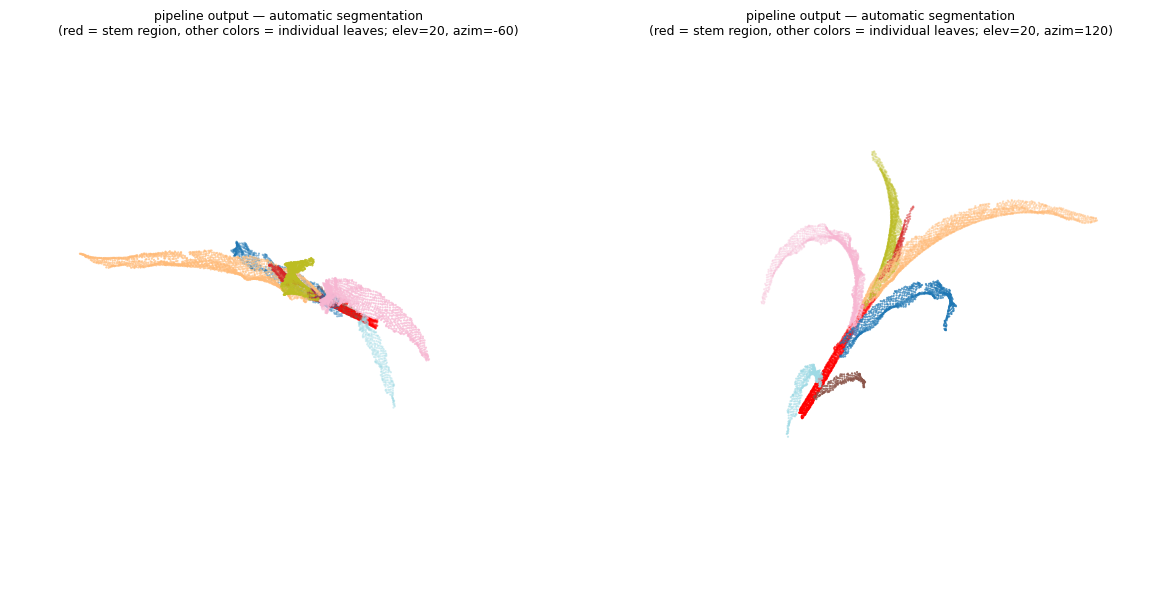

Author Verification_mt on sample 1 (single-sample values):


,value
metric,
precision,0.948795
recall,0.982032
micro_f1,0.965128
macro_f1,0.962989
overall_accuracy,0.970529



Per-organ precision / recall / F1 (gt_organ ordered by PLY file):


,gt_organ,precision,recall,f1,matched_auto_region
0,1,0.846635,0.990842,0.913080,1
1,2,1.000000,1.000000,1.000000,5
2,3,0.994413,0.986150,0.990264,8
3,4,0.997275,0.989189,0.993216,2
4,5,0.999243,0.995475,0.997355,6
5,6,1.000000,0.933721,0.965725,3
6,7,0.964753,0.960883,0.962814,7
7,8,0.788043,1.000000,0.881459,4



Reference (paper abstract, 75-seedling dataset level): mean P=0.944, R=0.956, micro-F1=0.950, OA=0.953


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

labels = pd.read_csv("/content/seg4maize/seg_labels.csv")["auto_label"].to_numpy()
pts = np.load("/content/pts_xyz.npy"); region = np.load("/content/pts_region.npy")
per_organ = pd.read_csv("/content/seg4maize/seg_per_organ.csv")
metrics = pd.read_csv("/content/seg4maize/seg_metrics.csv").set_index("metric")["value"]

stem_label = per_organ.loc[per_organ["gt_organ"] == 1, "matched_auto_region"].iloc[0]
is_stem = labels == stem_label

fig = plt.figure(figsize=(12, 6))
for k, (elev, azim) in enumerate([(20, -60), (20, 120)]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.scatter(pts[~is_stem, 0], pts[~is_stem, 1], pts[~is_stem, 2],
               s=0.3, c=labels[~is_stem], cmap="tab20")
    ax.scatter(pts[is_stem, 0], pts[is_stem, 1], pts[is_stem, 2], s=0.5, c="red")
    ax.view_init(elev=elev, azim=azim); ax.set_axis_off()
    ax.set_title(f"pipeline output — automatic segmentation\n(red = stem region, other colors = individual leaves; elev={elev}, azim={azim})", fontsize=9)
plt.tight_layout(); plt.savefig("seg_result_sample1.png", dpi=150); plt.show()

print("Author Verification_mt on sample 1 (single-sample values):")
display(metrics.to_frame("value"))
print("\nPer-organ precision / recall / F1 (gt_organ ordered by PLY file):")
display(per_organ)
per_organ.to_csv("seg_results_sample1.csv", index=False)
print(f"\nReference (paper abstract, 75-seedling dataset level): mean P=0.944, R=0.956, micro-F1=0.950, OA=0.953")

## 8. Interpretation, limitations, validation record / 解釈・限界・検証記録

**What was executed:** the released MATLAB pipeline (skeleton extraction → skeleton-based coarse segmentation → stem–leaf fine segmentation) ran unchanged, in execution order and parameters, on the released sample `testsample/1` with its released per-sample parameter file, under GNU Octave on Colab CPU. The author's own `Verification_mt` scored the automatic regions against the manual ground-truth regions bundled with the sample.

**How to read the numbers:** `Verification_mt` matches each ground-truth organ to the automatic region with the largest point intersection, then computes precision/recall/F1 per organ and overall accuracy (fraction of points in the matched regions). Single-sample values are **not** the paper's published 75-seedling means (P=0.944/R=0.956/micro-F1=0.950/OA=0.953); they are a plausibility check for this one plant.

**Limitations:**
- One sample; no benchmark, no trait extraction, no skeleton-optimization application, no method comparison (all outside the executed scope).
- MATLAB→Octave shims: `pcread`, `pointCloud`, `findNearestNeighbors`, `pcdenoise`, `pca`, the four `kdtree_*` entry points (the author's kd-tree ships only as Windows `.mexw64`), `movegui`, `graphtraverse`/`graphpred2path`/`graphshortestpath` are AI-generated with documented-equivalent semantics; eigenvector sign conventions do not affect the two `pca` call sites (projection/distance geometry only). All other author code runs unchanged.
- The journal full text is paywalled; acquisition setup and parameter *semantics* could not be cross-checked against the paper. All executed parameters come from the pinned repository itself.

/ **実行内容:** 公開MATLABパイプラインを、公開サンプル `testsample/1` と同梱パラメータファイルのまま Octave(Colab CPU)で実行し、著者の `Verification_mt` で手動正解と照合しました。単一サンプルの値は論文の75株平均ではありません。MATLAB→Octave のシム(5関数)はAI生成ですが意味は文書化済みで、著者のkd-treeコードは無変更です。論文本文は有料で、取得条件等は論文との突き合わせ未実施です。

## 9. References

- An, T. et al. (2021), doi:[10.1016/j.compag.2021.106310](https://doi.org/10.1016/j.compag.2021.106310)
- Code/data: [syau-miao/seg4maize](https://github.com/syau-miao/seg4maize) @ `bff81261ac3ea7dcded840a7a42dc1235ce8ddc2`, GPL-3.0
- Skeletonization basis cited by the code: Cao et al. 2010 Laplacian contraction; ROSA line extraction (bundled `skeleton/` sources)
- Precursor preprint (context only): arXiv:2009.03108
- Investigation context (prior research guidance, not primary proof): PhenoPaper investigation `p-128cba6ab1174fbf78bf2b45045261b8-20261007T090323Z-3909005`
